# Task 3

# Best Performing Model - Linear SVC - 0.698

## Preprocessing

Train: 111324 | Val: 27832
Variant: raw_no_stopwords
  Accuracy: 0.7629 | Macro F1: 0.6730
Variant: raw_with_stopwords_removed
  Accuracy: 0.7638 | Macro F1: 0.6795
Variant: lowercase_only
  Accuracy: 0.7629 | Macro F1: 0.6730
Variant: lowercase_with_stopwords_removed
  Accuracy: 0.7638 | Macro F1: 0.6795
Variant: remove_punct
  Accuracy: 0.7629 | Macro F1: 0.6730
Variant: remove_punct_with_stopwords_removed
  Accuracy: 0.7638 | Macro F1: 0.6795
Variant: remove_punct_digits
  Accuracy: 0.7621 | Macro F1: 0.6741
Variant: light_normalize_with_stopwords_removed
  Accuracy: 0.7652 | Macro F1: 0.6816

PREPROCESSING RESULTS (sorted by Macro F1):
                               variant  accuracy  macro_precision  macro_recall  macro_f1  weighted_f1
light_normalize_with_stopwords_removed  0.765162         0.717721      0.671698  0.681572     0.760792
            raw_with_stopwords_removed  0.763797         0.715077      0.669766  0.679485     0.759361
   remove_punct_with_stopwords_removed  0.7

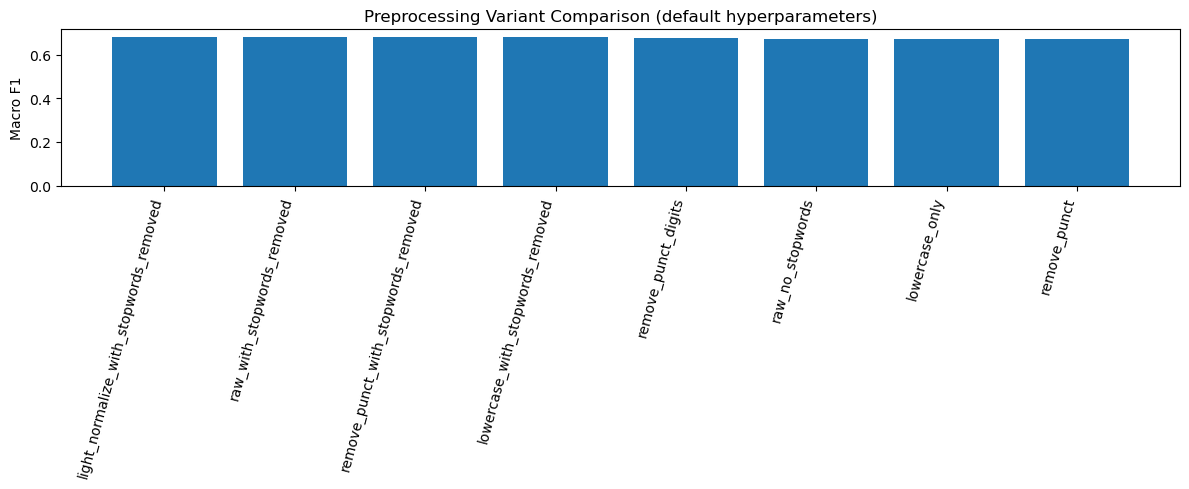


✓ Best preprocessing variant: light_normalize_with_stopwords_removed

Classification Report (validation):
              precision    recall  f1-score   support

           0       0.81      0.84      0.82      1555
           1       0.75      0.75      0.75       407
           2       0.80      0.86      0.83      1600
           3       0.53      0.20      0.29        94
           4       0.83      0.87      0.85      1600
           5       0.69      0.71      0.70      1600
           6       0.84      0.84      0.84      1600
           7       0.70      0.71      0.71       518
           8       0.66      0.53      0.59      1600
           9       0.77      0.80      0.79       997
          10       0.76      0.75      0.75      1427
          11       0.58      0.41      0.48       268
          12       0.82      0.86      0.84      1600
          13       0.46      0.24      0.32       286
          14       0.78      0.81      0.80      1527
          15       0.73     

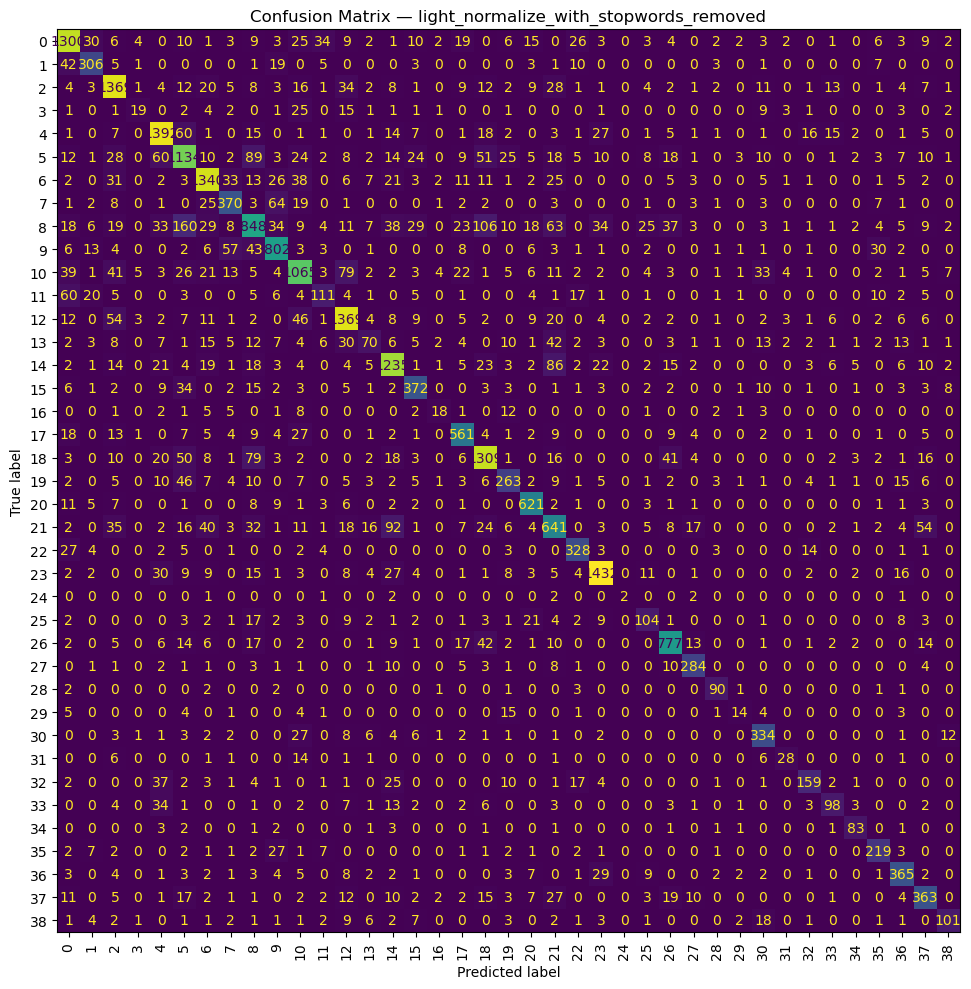


Saved: best_preprocessing_config.json


In [ ]:
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")
 
# 1. LOAD DATA
 
train_path = "../train.csv"
test_path  = "../test.csv"
 
train_df = pd.read_csv(train_path, sep="\t", engine="python", quotechar='"')
test_df  = pd.read_csv(test_path,  sep="\t", engine="python", quotechar='"')
 
X = train_df["abstract"].fillna("")
y = train_df["label_id"]
 
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
X_train = X_train.values
X_val   = X_val.values
y_train = y_train.values
y_val   = y_val.values
 
print(f"Train: {len(X_train)} | Val: {len(X_val)}")


# 2. PREPROCESSING FUNCTIONS
 
def identity_text(text):
    return str(text)
 
def lowercase_text(text):
    text = str(text).lower()
    return re.sub(r"\s+", " ", text).strip()
 
def remove_punct(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()
 
def remove_punct_digits(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    return re.sub(r"\s+", " ", text).strip()
 
def light_normalize(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    return re.sub(r"\s+", " ", text).strip()
 
 
# 3. PREPROCESSING VARIANTS
 
preprocessing_variants = {
    "raw_no_stopwords": {
        "text_func": identity_text,
        "tfidf_stopwords": None
    },
    "raw_with_stopwords_removed": {
        "text_func": identity_text,
        "tfidf_stopwords": "english"
    },
    "lowercase_only": {
        "text_func": lowercase_text,
        "tfidf_stopwords": None
    },
    "lowercase_with_stopwords_removed": {
        "text_func": lowercase_text,
        "tfidf_stopwords": "english"
    },
    "remove_punct": {
        "text_func": remove_punct,
        "tfidf_stopwords": None
    },
    "remove_punct_with_stopwords_removed": {
        "text_func": remove_punct,
        "tfidf_stopwords": "english"
    },
    "remove_punct_digits": {
        "text_func": remove_punct_digits,
        "tfidf_stopwords": None
    },
    "light_normalize_with_stopwords_removed": {
        "text_func": light_normalize,
        "tfidf_stopwords": "english"
    }
}
# =========================================================
# 4. DEFAULT HYPERPARAMETERS (fixed for this cell)
# =========================================================
 
DEFAULT_NGRAM    = (1, 2)
DEFAULT_MIN_DF   = 3
DEFAULT_MAX_DF   = 0.9
DEFAULT_C        = 1.0
DEFAULT_CW       = "balanced"
DEFAULT_SUBLIN   = True
 
 
def build_default_model(stopwords):
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=DEFAULT_NGRAM,
            min_df=DEFAULT_MIN_DF,
            max_df=DEFAULT_MAX_DF,
            stop_words=stopwords,
            sublinear_tf=DEFAULT_SUBLIN
        )),
        ("clf", LinearSVC(
            C=DEFAULT_C,
            class_weight=DEFAULT_CW,
            random_state=42,
            max_iter=2000
        ))
    ])
 
 
# 5. RUN PREPROCESSING EXPERIMENTS
 
results = []
 
for variant_name, cfg in preprocessing_variants.items():
    print("=" * 70)
    print(f"Variant: {variant_name}")
 
    X_train_proc = pd.Series(X_train).fillna("").apply(cfg["text_func"]).values
    X_val_proc   = pd.Series(X_val).fillna("").apply(cfg["text_func"]).values
 
    model = build_default_model(cfg["tfidf_stopwords"])
    model.fit(X_train_proc, y_train)
    y_pred = model.predict(X_val_proc)
 
    results.append({
        "variant":          variant_name,
        "accuracy":         accuracy_score(y_val, y_pred),
        "macro_precision":  precision_score(y_val, y_pred, average="macro", zero_division=0),
        "macro_recall":     recall_score(y_val, y_pred, average="macro", zero_division=0),
        "macro_f1":         f1_score(y_val, y_pred, average="macro", zero_division=0),
        "weighted_f1":      f1_score(y_val, y_pred, average="weighted", zero_division=0),
    })
 
    print(f"  Accuracy: {results[-1]['accuracy']:.4f} | Macro F1: {results[-1]['macro_f1']:.4f}")
 

# 6. RESULTS TABLE + PLOT
 
results_df = (
    pd.DataFrame(results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)
 
print("\nPREPROCESSING RESULTS (sorted by Macro F1):")
print(results_df.to_string(index=False))
 
plt.figure(figsize=(12, 5))
plt.bar(results_df["variant"], results_df["macro_f1"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Macro F1")
plt.title("Preprocessing Variant Comparison (default hyperparameters)")
plt.tight_layout()
plt.show()
 
 
# 7. EVALUATE BEST VARIANT IN DETAIL
 
best_variant_name = results_df.iloc[0]["variant"]
best_cfg = preprocessing_variants[best_variant_name]
 
print(f"\n✓ Best preprocessing variant: {best_variant_name}")
 
X_train_best = pd.Series(X_train).fillna("").apply(best_cfg["text_func"]).values
X_val_best   = pd.Series(X_val).fillna("").apply(best_cfg["text_func"]).values
 
best_model = build_default_model(best_cfg["tfidf_stopwords"])
best_model.fit(X_train_best, y_train)
y_pred_best = best_model.predict(X_val_best)
 
print("\nClassification Report (validation):")
print(classification_report(y_val, y_pred_best, zero_division=0))
 
cm = confusion_matrix(y_val, y_pred_best)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title(f"Confusion Matrix — {best_variant_name}")
plt.tight_layout()
plt.show()
 
 
# 8. SAVE BEST PREPROCESSING CONFIG FOR CELL 2
 
# Map function names to strings so they can be reconstructed in Cell 2
FUNC_NAME_MAP = {
    "identity_text":    "identity_text",
    "lowercase_text":   "lowercase_text",
    "remove_punct":     "remove_punct",
    "remove_punct_digits": "remove_punct_digits",
    "light_normalize":  "light_normalize",
}
 
config = {
    "best_variant":    best_variant_name,
    "text_func_name":  best_cfg["text_func"].__name__,
    "tfidf_stopwords": best_cfg["tfidf_stopwords"],
}
 
with open("best_preprocessing_config.json", "w") as f:
    json.dump(config, f, indent=2)
 
print("\nSaved: best_preprocessing_config.json")

## Hyperparameter Tuning

In [ ]:
import re
import json
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score


# 1. LOAD DATA

train_path = "../train.csv"
test_path  = "../test.csv"

train_df = pd.read_csv(train_path, sep="\t", engine="python", quotechar='"')
test_df  = pd.read_csv(test_path,  sep="\t", engine="python", quotechar='"')

X = train_df["abstract"].fillna("")
y = train_df["label_id"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.values
X_val   = X_val.values
y_train = y_train.values
y_val   = y_val.values

print(f"Train: {len(X_train)} | Val: {len(X_val)}")


# 2. LOAD BEST PREPROCESSING FROM CELL 1

def identity_text(text):
    return str(text)

def lowercase_text(text):
    text = str(text).lower()
    return re.sub(r"\s+", " ", text).strip()

def remove_punct(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def remove_punct_digits(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def light_normalize(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

FUNC_MAP = {
    "identity_text":        identity_text,
    "lowercase_text":       lowercase_text,
    "remove_punct":         remove_punct,
    "remove_punct_digits":  remove_punct_digits,
    "light_normalize":      light_normalize,
}

with open("best_preprocessing_config.json", "r") as f:
    prep_config = json.load(f)

best_text_func = FUNC_MAP[prep_config["text_func_name"]]
best_stopwords = prep_config["tfidf_stopwords"]

print(f"\n✓ Loaded preprocessing: {prep_config['best_variant']}")
print(f"  text_func   : {prep_config['text_func_name']}")
print(f"  stopwords   : {best_stopwords}")

# Apply best preprocessing once — reused across all experiments below
X_train_proc = pd.Series(X_train).fillna("").apply(best_text_func).values
X_val_proc   = pd.Series(X_val).fillna("").apply(best_text_func).values


# 3. HELPER: EVALUATE A PIPELINE

def evaluate(model, X_tr, y_tr, X_v, y_v, label=""):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    acc      = accuracy_score(y_v, y_pred)
    f1_macro = f1_score(y_v, y_pred, average="macro", zero_division=0)
    if label:
        print(f"  {label} → Accuracy: {acc:.4f} | Macro F1: {f1_macro:.4f}")
    return acc, f1_macro


# EXPERIMENT 1: NGRAM RANGE

print("\n" + "=" * 70)
print("EXPERIMENT 1: NGRAM RANGE")
print("=" * 70)

ngram_results = []
for ngram in [(1, 1), (1, 2), (1, 3), (2, 2)]:
    model = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=ngram, min_df=3, max_df=0.9,
                                   stop_words=best_stopwords, sublinear_tf=True)),
        ("clf",   LinearSVC(C=1.0, class_weight="balanced", random_state=42, max_iter=2000))
    ])
    acc, f1 = evaluate(model, X_train_proc, y_train, X_val_proc, y_val,
                       label=f"ngram={ngram}")
    ngram_results.append({"ngram_range": str(ngram), "accuracy": acc, "macro_f1": f1})

ngram_df = pd.DataFrame(ngram_results).sort_values("macro_f1", ascending=False)
best_ngram = eval(ngram_df.iloc[0]["ngram_range"])
print(f"\n✓ Best ngram_range: {best_ngram}")


# EXPERIMENT 2: MIN_DF / MAX_DF

print("\n" + "=" * 70)
print("EXPERIMENT 2: MIN_DF / MAX_DF")
print("=" * 70)

minmax_results = []
for min_df in [1, 2, 3, 5]:
    for max_df in [0.8, 0.9, 0.95]:
        model = Pipeline([
            ("tfidf", TfidfVectorizer(ngram_range=best_ngram, min_df=min_df, max_df=max_df,
                                       stop_words=best_stopwords, sublinear_tf=True)),
            ("clf",   LinearSVC(C=1.0, class_weight="balanced", random_state=42, max_iter=2000))
        ])
        acc, f1 = evaluate(model, X_train_proc, y_train, X_val_proc, y_val,
                           label=f"min_df={min_df}, max_df={max_df}")
        minmax_results.append({"min_df": min_df, "max_df": max_df,
                                "accuracy": acc, "macro_f1": f1})

minmax_df = pd.DataFrame(minmax_results).sort_values("macro_f1", ascending=False)
best_min_df = int(minmax_df.iloc[0]["min_df"])
best_max_df = float(minmax_df.iloc[0]["max_df"])
print(f"\n✓ Best min_df={best_min_df}, max_df={best_max_df}")
print(minmax_df.head())



Train: 111324 | Val: 27832

✓ Loaded preprocessing: light_normalize_with_stopwords_removed
  text_func   : light_normalize
  stopwords   : english

EXPERIMENT 1: NGRAM RANGE
  ngram=(1, 1) → Accuracy: 0.7356 | Macro F1: 0.6488
  ngram=(1, 2) → Accuracy: 0.7652 | Macro F1: 0.6816
  ngram=(1, 3) → Accuracy: 0.7643 | Macro F1: 0.6778
  ngram=(2, 2) → Accuracy: 0.7247 | Macro F1: 0.6274

✓ Best ngram_range: (1, 2)

EXPERIMENT 2: MIN_DF / MAX_DF
  min_df=1, max_df=0.8 → Accuracy: 0.7665 | Macro F1: 0.6768
  min_df=1, max_df=0.9 → Accuracy: 0.7665 | Macro F1: 0.6768
  min_df=1, max_df=0.95 → Accuracy: 0.7665 | Macro F1: 0.6768
  min_df=2, max_df=0.8 → Accuracy: 0.7652 | Macro F1: 0.6772
  min_df=2, max_df=0.9 → Accuracy: 0.7652 | Macro F1: 0.6772
  min_df=2, max_df=0.95 → Accuracy: 0.7652 | Macro F1: 0.6772
  min_df=3, max_df=0.8 → Accuracy: 0.7652 | Macro F1: 0.6816
  min_df=3, max_df=0.9 → Accuracy: 0.7652 | Macro F1: 0.6816
  min_df=3, max_df=0.95 → Accuracy: 0.7652 | Macro F1: 0.6816
  m

In [ ]:
# EXPERIMENT 3: C PARAMETER

print("\n" + "=" * 70)
print("EXPERIMENT 3: LinearSVC C PARAMETER")
print("=" * 70)

c_results = []
for C in [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
    model = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=best_ngram, min_df=best_min_df,
                                   max_df=best_max_df, stop_words=best_stopwords,
                                   sublinear_tf=True)),
        ("clf",   LinearSVC(C=C, class_weight="balanced", random_state=42, max_iter=2000))
    ])
    acc, f1 = evaluate(model, X_train_proc, y_train, X_val_proc, y_val, label=f"C={C}")
    c_results.append({"C": C, "accuracy": acc, "macro_f1": f1})

c_df = pd.DataFrame(c_results).sort_values("macro_f1", ascending=False)
best_C = float(c_df.iloc[0]["C"])
print(f"\n✓ Best C: {best_C}")


EXPERIMENT 3: LinearSVC C PARAMETER
  C=0.1 → Accuracy: 0.7454 | Macro F1: 0.6590
  C=0.5 → Accuracy: 0.7618 | Macro F1: 0.6781
  C=1.0 → Accuracy: 0.7652 | Macro F1: 0.6816
  C=2.0 → Accuracy: 0.7625 | Macro F1: 0.6751
  C=5.0 → Accuracy: 0.7595 | Macro F1: 0.6704
  C=10.0 → Accuracy: 0.7579 | Macro F1: 0.6689

✓ Best C: 1.0


In [ ]:
# EXPERIMENT 4: CLASS_WEIGHT

print("\n" + "=" * 70)
print("EXPERIMENT 4: CLASS_WEIGHT")
print("=" * 70)

cw_results = []
for cw in [None, "balanced"]:
    model = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=best_ngram, min_df=best_min_df,
                                   max_df=best_max_df, stop_words=best_stopwords,
                                   sublinear_tf=True)),
        ("clf",   LinearSVC(C=best_C, class_weight=cw, random_state=42, max_iter=2000))
    ])
    acc, f1 = evaluate(model, X_train_proc, y_train, X_val_proc, y_val,
                       label=f"class_weight={cw}")
    cw_results.append({"class_weight": str(cw), "accuracy": acc, "macro_f1": f1})

cw_df = pd.DataFrame(cw_results).sort_values("macro_f1", ascending=False)
best_cw = cw_df.iloc[0]["class_weight"]
# Convert string back to None if needed
best_cw_value = None if best_cw == "None" else best_cw
print(f"\n✓ Best class_weight: {best_cw_value}")

# 6. SUMMARY

print("\n" + "=" * 70)
print("BEST HYPERPARAMETERS FOUND")
print("=" * 70)
print(f"  ngram_range  : {best_ngram}")
print(f"  min_df       : {best_min_df}")
print(f"  max_df       : {best_max_df}")
print(f"  C            : {best_C}")
print(f"  class_weight : {best_cw_value}")


# 7. SAVE BEST HYPERPARAMS FOR CELL 3

hyperparam_config = {
    "ngram_range":   list(best_ngram),
    "min_df":        int(best_min_df),
    "max_df":        float(best_max_df),
    "C":             float(best_C),
    "class_weight":  best_cw_value,
}

with open("best_hyperparams_config.json", "w") as f:
    json.dump(hyperparam_config, f, indent=2)

print("\nSaved: best_hyperparams_config.json")
print("→ Now run Cell 3 (final model + submission).")


EXPERIMENT 4: CLASS_WEIGHT
  class_weight=None → Accuracy: 0.7625 | Macro F1: 0.6674
  class_weight=balanced → Accuracy: 0.7652 | Macro F1: 0.6816

✓ Best class_weight: balanced

BEST HYPERPARAMETERS FOUND
  ngram_range  : (1, 2)
  min_df       : 3
  max_df       : 0.8
  C            : 1.0
  class_weight : balanced

Saved: best_hyperparams_config.json
→ Now run Cell 3 (final model + submission).


## Final model + Submission csv

This cell loads the best preprocessing from best_preprocessing_config.json and the best hyperparameters from best_hyperparams_config.json.
- It trains on the train split of the train/val split, and evaluates on the validation split.
- Finally, it retrains on the full train + val data and predicts on test, outputting LinearSVM_FinalModel.csv with the predicted test values.

Train: 111324 | Val: 27832 | Test: 34790

✓ Preprocessing : light_normalize_with_stopwords_removed
  text_func     : light_normalize
  stopwords     : english

✓ Hyperparameters loaded:
  ngram_range: [1, 2]
  min_df: 3
  max_df: 0.8
  C: 1.0
  class_weight: balanced

VALIDATION CHECK (train split only)
  Accuracy       : 0.7652
  Macro F1       : 0.6816
  Weighted F1    : 0.7608
  Macro Precision: 0.7177
  Macro Recall   : 0.6717

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82      1555
           1       0.75      0.75      0.75       407
           2       0.80      0.86      0.83      1600
           3       0.53      0.20      0.29        94
           4       0.83      0.87      0.85      1600
           5       0.69      0.71      0.70      1600
           6       0.84      0.84      0.84      1600
           7       0.70      0.71      0.71       518
           8       0.66      0.53      0.59      1600


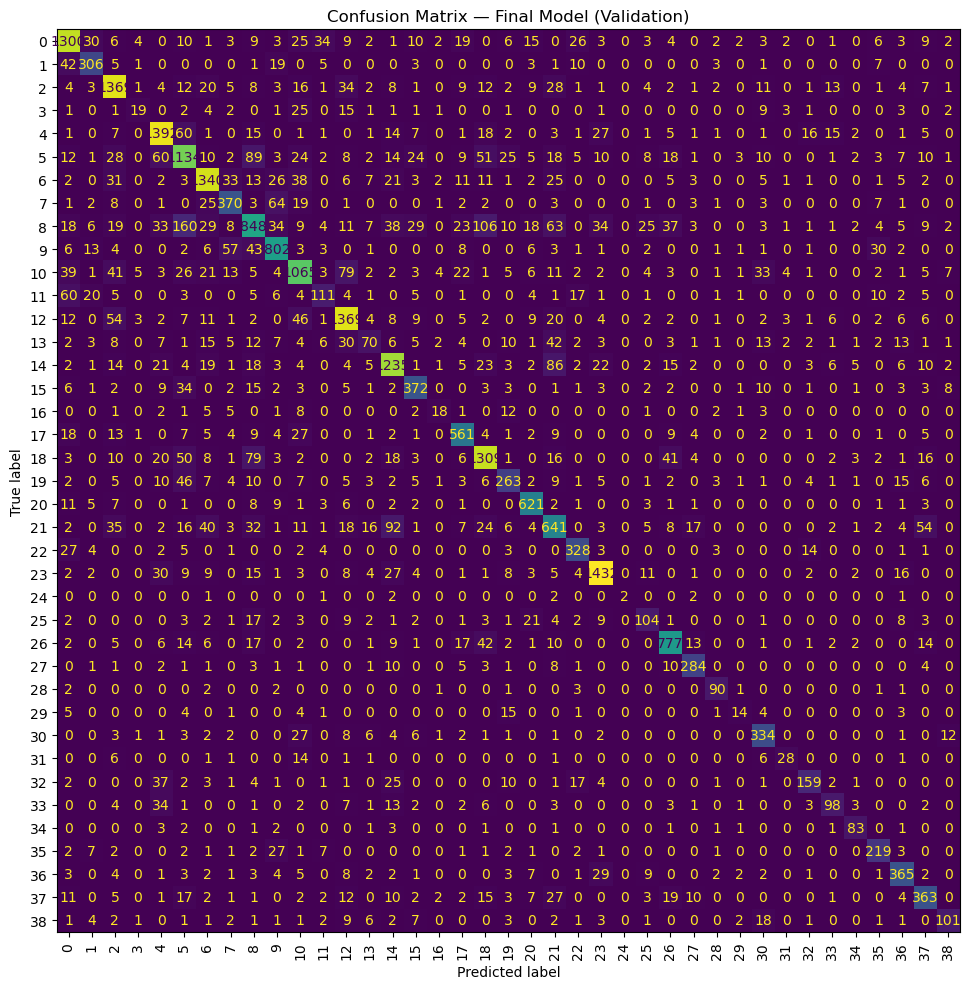


RETRAINING ON FULL DATA (train + val)
Final model trained on full dataset.

Submission saved: submission.csv
       id  label_id
0  173148        38
1   29098         4
2   28211         4
3  136101         0
4   97133        14

FINAL CONFIGURATION SUMMARY
  Preprocessing  : light_normalize_with_stopwords_removed
  text_func      : light_normalize
  stopwords      : english
  ngram_range    : [1, 2]
  min_df         : 3
  max_df         : 0.8
  C              : 1.0
  class_weight   : balanced
DONE.


In [ ]:
import re
import json
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# 1. LOAD DATA

train_path = "../train.csv"
test_path  = "../test.csv"

train_df = pd.read_csv(train_path, sep="\t", engine="python", quotechar='"')
test_df  = pd.read_csv(test_path,  sep="\t", engine="python", quotechar='"')

X_all   = train_df["abstract"].fillna("")
y_all   = train_df["label_id"]
X_test  = test_df["abstract"].fillna("")
test_ids = test_df["id"]

# Keep a held-out val split for final validation reporting only
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Train: {len(X_train_raw)} | Val: {len(X_val_raw)} | Test: {len(X_test)}")


# 2. LOAD BEST PREPROCESSING (from Cell 1)

def identity_text(text):
    return str(text)

def lowercase_text(text):
    text = str(text).lower()
    return re.sub(r"\s+", " ", text).strip()

def remove_punct(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def remove_punct_digits(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def light_normalize(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

FUNC_MAP = {
    "identity_text":        identity_text,
    "lowercase_text":       lowercase_text,
    "remove_punct":         remove_punct,
    "remove_punct_digits":  remove_punct_digits,
    "light_normalize":      light_normalize,
}

with open("best_preprocessing_config.json", "r") as f:
    prep_config = json.load(f)

text_func    = FUNC_MAP[prep_config["text_func_name"]]
best_stopwords = prep_config["tfidf_stopwords"]

print(f"\n✓ Preprocessing : {prep_config['best_variant']}")
print(f"  text_func     : {prep_config['text_func_name']}")
print(f"  stopwords     : {best_stopwords}")


# 3. LOAD BEST HYPERPARAMETERS (from Cell 2)

with open("best_hyperparams_config.json", "r") as f:
    hp = json.load(f)

print(f"\n✓ Hyperparameters loaded:")
for k, v in hp.items():
    print(f"  {k}: {v}")


# 4. VALIDATE ON HELD-OUT SET (sanity check before final train)

print("\n" + "=" * 70)
print("VALIDATION CHECK (train split only)")
print("=" * 70)

X_train_proc = pd.Series(X_train_raw.values).fillna("").apply(text_func).values
X_val_proc   = pd.Series(X_val_raw.values).fillna("").apply(text_func).values
y_train_arr  = y_train_raw.values
y_val_arr    = y_val_raw.values

val_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=tuple(hp["ngram_range"]),
        min_df=hp["min_df"],
        max_df=hp["max_df"],
        stop_words=best_stopwords,
        sublinear_tf=True
    )),
    ("clf", LinearSVC(
        C=hp["C"],
        class_weight=hp["class_weight"],
        random_state=42,
        max_iter=2000
    ))
])

val_model.fit(X_train_proc, y_train_arr)
y_val_pred = val_model.predict(X_val_proc)

print(f"  Accuracy       : {accuracy_score(y_val_arr, y_val_pred):.4f}")
print(f"  Macro F1       : {f1_score(y_val_arr, y_val_pred, average='macro', zero_division=0):.4f}")
print(f"  Weighted F1    : {f1_score(y_val_arr, y_val_pred, average='weighted', zero_division=0):.4f}")
print(f"  Macro Precision: {precision_score(y_val_arr, y_val_pred, average='macro', zero_division=0):.4f}")
print(f"  Macro Recall   : {recall_score(y_val_arr, y_val_pred, average='macro', zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(y_val_arr, y_val_pred, zero_division=0))

cm = confusion_matrix(y_val_arr, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Confusion Matrix — Final Model (Validation)")
plt.tight_layout()
plt.show()


# 5. RETRAIN ON FULL TRAIN + VAL DATA

print("\n" + "=" * 70)
print("RETRAINING ON FULL DATA (train + val)")
print("=" * 70)

X_full_proc = pd.Series(X_all.values).fillna("").apply(text_func).values
y_full      = y_all.values

final_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=tuple(hp["ngram_range"]),
        min_df=hp["min_df"],
        max_df=hp["max_df"],
        stop_words=best_stopwords,
        sublinear_tf=True
    )),
    ("clf", LinearSVC(
        C=hp["C"],
        class_weight=hp["class_weight"],
        random_state=42,
        max_iter=2000
    ))
])

final_model.fit(X_full_proc, y_full)
print("Final model trained on full dataset.")


# 6. PREDICT ON TEST SET + SAVE SUBMISSION

X_test_proc = pd.Series(X_test.values).fillna("").apply(text_func).values
test_pred   = final_model.predict(X_test_proc)

submission = pd.DataFrame({
    "id":       test_ids.values,
    "label_id": test_pred
})

submission.to_csv("submission.csv", index=False)

print("\nSubmission saved: submission.csv")
print(submission.head())


# 7. FINAL CONFIG SUMMARY

print("\n" + "=" * 70)
print("FINAL CONFIGURATION SUMMARY")
print("=" * 70)
print(f"  Preprocessing  : {prep_config['best_variant']}")
print(f"  text_func      : {prep_config['text_func_name']}")
print(f"  stopwords      : {best_stopwords}")
for k, v in hp.items():
    print(f"  {k:<15}: {v}")
print("=" * 70)
print("DONE.")

# Soft ensemble - 0.685

### Final model for Softensemble  - 0.685

In [2]:
import numpy as np
import pandas as pd
import re
import time
import warnings
warnings.filterwarnings("ignore")

from scipy.sparse import hstack
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — skipping. Install with: pip install xgboost")


# =========================
# 1. Load data
# =========================
def load_data(train_path="../train.csv", test_path="../test.csv"):
    train_df = pd.read_csv(train_path, sep="\t", engine="python", quotechar='"')
    test_df = pd.read_csv(test_path, sep="\t", engine="python", quotechar='"')

    print(f"Loaded train: {train_df.shape}, test: {test_df.shape}")
    print("Train columns:", train_df.columns.tolist())
    print("Test columns :", test_df.columns.tolist())
    return train_df, test_df


# =========================
# 2. Best preprocessing
# =========================
def light_normalize(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)   # remove punctuation
    text = re.sub(r"\d+", " ", text)       # remove digits
    text = re.sub(r"\s+", " ", text).strip()
    return text


# =========================
# 3. Feature builder
# =========================
def build_feature_pipeline(
    X_train_text,
    X_other_text,
    word_ngram=(1, 2),
    word_max=80000,
    char_ngram=(3, 5),
    char_max=30000
):
    # word tfidf
    word_vec = TfidfVectorizer(
        ngram_range=word_ngram,
        max_features=word_max,
        sublinear_tf=True,
        min_df=3,
        max_df=0.95,
        analyzer="word",
        stop_words="english",          # same as best setup
        strip_accents="unicode",
        token_pattern=r"\w{2,}"
    )

    Xw_train = word_vec.fit_transform(X_train_text)
    Xw_other = word_vec.transform(X_other_text)

    # char tfidf
    char_vec = TfidfVectorizer(
        ngram_range=char_ngram,
        max_features=char_max,
        sublinear_tf=True,
        min_df=3,
        analyzer="char_wb",
        strip_accents="unicode"
    )

    Xc_train = char_vec.fit_transform(X_train_text)
    Xc_other = char_vec.transform(X_other_text)

    # combined sparse matrix
    X_sparse_train = hstack([Xw_train, Xc_train]).tocsr()
    X_sparse_other = hstack([Xw_other, Xc_other]).tocsr()

    return X_sparse_train, X_sparse_other


# =========================
# 4. Models
# =========================
def get_sparse_model_zoo():
    models = {
        "ComplementNB": ComplementNB(alpha=0.3),

        "LogisticRegression": LogisticRegression(
            C=6.0,
            max_iter=2000,
            solver="lbfgs",
            n_jobs=-1,
            random_state=42
        ),

        "LinearSVC": CalibratedClassifierCV(
            estimator=LinearSVC(
                C=1.0,
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            ),
            method="sigmoid",
            cv=5
        ),

        "SGD_SVM": SGDClassifier(
            loss="modified_huber",
            alpha=5e-5,
            max_iter=1000,
            tol=1e-3,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42
        ),
    }
    return models


FAST_MODELS = {"ComplementNB", "LogisticRegression", "SGD_SVM"}


# =========================
# 5. Train + evaluate single model
# =========================
def train_evaluate(name, model, X_train, y_train, X_val, y_val):
    start = time.time()

    if name in FAST_MODELS:
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="f1_macro",
            n_jobs=-1
        )
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
    else:
        cv_mean = np.nan
        cv_std = np.nan

    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)

    val_acc = accuracy_score(y_val, val_pred)
    val_f1 = f1_score(y_val, val_pred, average="macro")
    elapsed = time.time() - start

    print(
        f"{name:<20} | "
        f"CV F1: {cv_mean if not np.isnan(cv_mean) else 'skip'} | "
        f"Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | "
        f"Time: {elapsed:.2f}s"
    )

    return {
        "model": name,
        "cv_f1_mean": cv_mean,
        "cv_f1_std": cv_std,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "time_s": round(elapsed, 2)
    }, model


# =========================
# 6. Ensemble helpers
# =========================
def get_probabilities(fitted_models, X_val_sparse, selected_model_names=None):
    probas = {}
    class_labels = None

    for name, model in fitted_models.items():
        if selected_model_names is not None and name not in selected_model_names:
            continue

        if hasattr(model, "predict_proba"):
            p = model.predict_proba(X_val_sparse)
            probas[name] = p
            if class_labels is None and hasattr(model, "classes_"):
                class_labels = model.classes_

    return probas, class_labels


def evaluate_equal_soft_voting(probas_dict, class_labels, y_val):
    if len(probas_dict) == 0:
        return None, None

    probas = np.stack(list(probas_dict.values()), axis=0)
    avg_proba = probas.mean(axis=0)

    if class_labels is None:
        y_pred = np.argmax(avg_proba, axis=1)
    else:
        y_pred = class_labels[np.argmax(avg_proba, axis=1)]

    val_acc = accuracy_score(y_val, y_pred)
    val_f1 = f1_score(y_val, y_pred, average="macro")

    print(f"{'SoftVotingEqual':<20} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    return {
        "model": "SoftVotingEqual",
        "cv_f1_mean": np.nan,
        "cv_f1_std": np.nan,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "time_s": 0.0
    }, y_pred


def evaluate_weighted_soft_voting(probas_dict, class_labels, y_val, weights, label="SoftVotingWeighted"):
    selected_names = [name for name in weights if name in probas_dict]
    if len(selected_names) == 0:
        return None, None

    probas = np.stack([probas_dict[name] for name in selected_names], axis=0)
    w = np.array([weights[name] for name in selected_names], dtype=float)
    w = w / w.sum()

    avg_proba = np.tensordot(w, probas, axes=(0, 0))

    if class_labels is None:
        y_pred = np.argmax(avg_proba, axis=1)
    else:
        y_pred = class_labels[np.argmax(avg_proba, axis=1)]

    val_acc = accuracy_score(y_val, y_pred)
    val_f1 = f1_score(y_val, y_pred, average="macro")

    print(f"{label:<20} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | Weights: {weights}")

    return {
        "model": label,
        "cv_f1_mean": np.nan,
        "cv_f1_std": np.nan,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "time_s": 0.0
    }, y_pred


def search_weighted_ensembles(probas_dict, class_labels, y_val):
    candidate_weights = [
        {"LinearSVC": 0.50, "SGD_SVM": 0.30, "LogisticRegression": 0.20},
        {"LinearSVC": 0.45, "SGD_SVM": 0.35, "LogisticRegression": 0.20},
        {"LinearSVC": 0.40, "SGD_SVM": 0.35, "LogisticRegression": 0.25},
        {"LinearSVC": 0.45, "SGD_SVM": 0.30, "LogisticRegression": 0.20, "ComplementNB": 0.05},
        {"LinearSVC": 0.40, "SGD_SVM": 0.30, "LogisticRegression": 0.25, "ComplementNB": 0.05},
        {"LinearSVC": 0.50, "SGD_SVM": 0.25, "LogisticRegression": 0.20, "ComplementNB": 0.05},
    ]

    best_result = None
    best_pred = None
    best_weights = None

    print("\nSearching weighted ensembles...")
    print("-" * 72)

    for i, weights in enumerate(candidate_weights, start=1):
        label = f"WeightedSoftVote_{i}"
        result, y_pred = evaluate_weighted_soft_voting(
            probas_dict, class_labels, y_val, weights, label=label
        )

        if result is not None:
            if (best_result is None) or (result["val_f1"] > best_result["val_f1"]):
                best_result = result
                best_pred = y_pred
                best_weights = weights

    return best_result, best_pred, best_weights


# =========================
# 7. Fit final ensemble on full train
# =========================
def fit_full_ensemble_and_predict(X_full, y_full, X_test, weights):
    print("\nBuilding full-train/test features for ensemble...")
    X_sp_full, X_sp_test = build_feature_pipeline(X_full, X_test)

    models = get_sparse_model_zoo()

    probas = []
    class_labels = None
    used_weights = []

    for name, model in models.items():
        if name not in weights:
            continue

        print(f"Fitting full model: {name}")
        model.fit(X_sp_full, y_full)

        if hasattr(model, "predict_proba"):
            p = model.predict_proba(X_sp_test)
            probas.append(p)
            used_weights.append(weights[name])

            if class_labels is None and hasattr(model, "classes_"):
                class_labels = model.classes_

    probas = np.stack(probas, axis=0)
    used_weights = np.array(used_weights, dtype=float)
    used_weights = used_weights / used_weights.sum()

    avg_proba = np.tensordot(used_weights, probas, axes=(0, 0))

    if class_labels is None:
        test_pred = np.argmax(avg_proba, axis=1)
    else:
        test_pred = class_labels[np.argmax(avg_proba, axis=1)]

    return test_pred


# =========================
# 8. Main
# =========================
def main():
    print("=" * 72)
    print("ArXiv CS Subcategory Classification")
    print("Train on split -> validate ensemble -> retrain best ensemble -> predict test")
    print("=" * 72)

    # load
    train_df, test_df = load_data()

    # apply BEST preprocessing everywhere
    train_df["abstract"] = train_df["abstract"].fillna("").apply(light_normalize)
    test_df["abstract"] = test_df["abstract"].fillna("").apply(light_normalize)

    X = train_df["abstract"]
    y = train_df["label_id"].values

    # split
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print(f"\nTrain size: {len(X_train)}")
    print(f"Val size  : {len(X_val)}")
    print(f"Classes   : {len(np.unique(y))}")

    # features
    print("\nBuilding train/val features...")
    X_sp_train, X_sp_val = build_feature_pipeline(X_train, X_val)

    # model benchmarking
    models = get_sparse_model_zoo()
    results = []
    fitted_sparse_models = {}

    print("\nSparse model benchmarking:")
    print("-" * 72)

    for name, model in models.items():
        result, fitted_model = train_evaluate(name, model, X_sp_train, y_train, X_sp_val, y_val)
        results.append(result)
        fitted_sparse_models[name] = fitted_model

    # get probabilities
    probas_dict, class_labels = get_probabilities(fitted_sparse_models, X_sp_val)

    # equal vote
    equal_result, equal_pred = evaluate_equal_soft_voting(probas_dict, class_labels, y_val)
    if equal_result is not None:
        results.append(equal_result)

    # weighted search
    best_weighted_result, best_weighted_pred, best_weights = search_weighted_ensembles(
        probas_dict, class_labels, y_val
    )
    if best_weighted_result is not None:
        results.append(best_weighted_result)

    # leaderboard
    results_df = pd.DataFrame(results).sort_values("val_f1", ascending=False).reset_index(drop=True)
    print("\nValidation leaderboard:")
    print(results_df.to_string(index=False))

    # best overall
    best_name = results_df.iloc[0]["model"]
    print(f"\nBest validation system: {best_name}")

    if best_weighted_result is not None:
        print("Best ensemble weights:", best_weights)

    # report for best system
    if best_name == "SoftVotingEqual":
        best_pred = equal_pred
    elif best_weighted_result is not None and best_name == best_weighted_result["model"]:
        best_pred = best_weighted_pred
    else:
        best_pred = fitted_sparse_models[best_name].predict(X_sp_val)

    print(f"\nClassification report for best validation system: {best_name}")
    print(classification_report(y_val, best_pred, digits=4))

    results_df.to_csv("model_results_best_preproc.csv", index=False)
    print("\nSaved validation results to model_results_best_preproc.csv")

    # final retrain
    print("\nRetraining best system on full train.csv...")
    X_full = train_df["abstract"]
    y_full = train_df["label_id"].values
    X_test = test_df["abstract"]

    if best_name in fitted_sparse_models:
        print(f"Final system is single model: {best_name}")

        X_sp_full, X_sp_test = build_feature_pipeline(X_full, X_test)
        final_model = get_sparse_model_zoo()[best_name]
        final_model.fit(X_sp_full, y_full)
        test_pred = final_model.predict(X_sp_test)

    elif best_name == "SoftVotingEqual":
        equal_weights = {
            "ComplementNB": 1.0,
            "LogisticRegression": 1.0,
            "LinearSVC": 1.0,
            "SGD_SVM": 1.0
        }
        test_pred = fit_full_ensemble_and_predict(X_full, y_full, X_test, equal_weights)

    else:
        test_pred = fit_full_ensemble_and_predict(X_full, y_full, X_test, best_weights)

    submission = pd.DataFrame({
        "id": test_df["id"],
        "label_id": test_pred
    })

    submission.to_csv("submission_best_preproc_ensemble.csv", index=False)
    print("Saved submission to submission_best_preproc_ensemble.csv")

    print("\nSubmission preview:")
    print(submission.head())

    return results_df, submission


if __name__ == "__main__":
    results_df, submission_df = main()

ArXiv CS Subcategory Classification
Train on split -> validate ensemble -> retrain best ensemble -> predict test
Loaded train: (139156, 3), test: (34790, 2)
Train columns: ['id', 'abstract', 'label_id']
Test columns : ['id', 'abstract']

Train size: 111324
Val size  : 27832
Classes   : 39

Building train/val features...

Sparse model benchmarking:
------------------------------------------------------------------------
ComplementNB         | CV F1: 0.4850564908712654 | Val Acc: 0.6769 | Val F1: 0.4760 | Time: 12.33s
LogisticRegression   | CV F1: 0.6547880652672536 | Val Acc: 0.7463 | Val F1: 0.6551 | Time: 1356.71s
LinearSVC            | CV F1: skip | Val Acc: 0.7538 | Val F1: 0.6682 | Time: 340.18s
SGD_SVM              | CV F1: 0.6610591424772921 | Val Acc: 0.7505 | Val F1: 0.6662 | Time: 42.77s
SoftVotingEqual      | Val Acc: 0.7553 | Val F1: 0.6699

Searching weighted ensembles...
------------------------------------------------------------------------
WeightedSoftVote_1   | Val Acc

### Soft Ensemble Version 2 - 0.639

In [ ]:
# ============================================================
# WEAKER / BASELINE SOFT-VOTING ENSEMBLE
# - simpler features
# - equal weights only
# - no class balancing
# - smaller feature space
# - simpler calibration
# ============================================================

import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings("ignore")

from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV


# =========================
# 1. Load data
# =========================
def load_data(train_path="train.csv", test_path="test.csv"):
    train_df = pd.read_csv(train_path, sep="\t", engine="python", quotechar='"')
    test_df = pd.read_csv(test_path, sep="\t", engine="python", quotechar='"')
    print(f"Loaded train: {train_df.shape}")
    print(f"Loaded test : {test_df.shape}")
    return train_df, test_df


# =========================
# 2. Light preprocessing
# =========================
def light_normalize(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# =========================
# 3. Simpler feature builder
#    weaker than your strong version:
#    - only word TF-IDF
#    - unigrams only
#    - smaller max_features
# =========================
def build_features(X_train_text, X_other_text):
    word_vec = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 1),      # weaker: unigrams only
        max_features=30000,      # weaker: fewer features
        min_df=5,                # more aggressive pruning
        max_df=0.90,
        sublinear_tf=False,      # weaker: no sublinear tf
        stop_words="english",
        strip_accents="unicode",
        token_pattern=r"\w{2,}"
    )

    X_train = word_vec.fit_transform(X_train_text)
    X_other = word_vec.transform(X_other_text)

    print("Feature shape (train):", X_train.shape)
    print("Feature shape (other):", X_other.shape)

    return X_train, X_other, word_vec


# =========================
# 4. Baseline models
# =========================
def build_models():
    models = {
        "ComplementNB": ComplementNB(alpha=1.0),   # default-ish, stronger smoothing than 0.3

        "LogisticRegression": LogisticRegression(
            C=1.0,
            max_iter=1000,
            solver="lbfgs",
            random_state=42
        ),

        "LinearSVC": CalibratedClassifierCV(
            estimator=LinearSVC(
                C=1.0,
                max_iter=3000,
                random_state=42
            ),
            method="sigmoid",
            cv=2   # weaker/faster than 5-fold calibration
        ),

        "SGDClassifier": SGDClassifier(
            loss="log_loss",   # simpler baseline
            alpha=1e-4,
            max_iter=1000,
            tol=1e-3,
            random_state=42
        )
    }
    return models


# =========================
# 5. Evaluate individual models
# =========================
def evaluate_individual_models(models, X_train, y_train, X_val, y_val):
    fitted_models = {}
    rows = []

    print("\nIndividual model performance")
    print("-" * 70)

    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)

        val_pred = model.predict(X_val)
        val_acc = accuracy_score(y_val, val_pred)
        val_f1 = f1_score(y_val, val_pred, average="macro")

        print(f"{name:<20} | Val Acc: {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")

        fitted_models[name] = model
        rows.append({
            "model": name,
            "val_acc": val_acc,
            "val_macro_f1": val_f1
        })

    return fitted_models, pd.DataFrame(rows)


# =========================
# 6. Get probabilities
# =========================
def get_probabilities(fitted_models, X):
    probas = {}
    ref_classes = None

    for name, model in fitted_models.items():
        p = model.predict_proba(X)
        cls = model.classes_

        if ref_classes is None:
            ref_classes = cls
            probas[name] = p
        else:
            if np.array_equal(cls, ref_classes):
                probas[name] = p
            else:
                aligned = np.zeros((p.shape[0], len(ref_classes)), dtype=np.float32)
                cls_to_idx = {c: i for i, c in enumerate(cls)}
                for j, c in enumerate(ref_classes):
                    aligned[:, j] = p[:, cls_to_idx[c]]
                probas[name] = aligned

    return probas, ref_classes


# =========================
# 7. Equal-weight soft voting only
#    weaker than weighted search
# =========================
def soft_vote_predict(probas_dict, class_labels):
    model_names = list(probas_dict.keys())
    probs = np.stack([probas_dict[m] for m in model_names], axis=0)

    avg_proba = probs.mean(axis=0)   # equal weights only
    y_pred = class_labels[np.argmax(avg_proba, axis=1)]
    return y_pred


# =========================
# 8. Main
# =========================
def main(train_path="train.csv", test_path="test.csv"):
    print("=" * 80)
    print("BASELINE SOFT-VOTING ENSEMBLE")
    print("=" * 80)

    train_df, test_df = load_data(train_path, test_path)

    train_df["abstract"] = train_df["abstract"].fillna("").apply(light_normalize)
    test_df["abstract"] = test_df["abstract"].fillna("").apply(light_normalize)

    X = train_df["abstract"]
    y = train_df["label_id"].values

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\nTrain size: {len(X_train)}")
    print(f"Val size  : {len(X_val)}")
    print(f"Classes   : {len(np.unique(y))}")

    X_train_sp, X_val_sp, vec = build_features(X_train, X_val)

    models = build_models()
    fitted_models, individual_results_df = evaluate_individual_models(
        models, X_train_sp, y_train, X_val_sp, y_val
    )

    probas_dict, class_labels = get_probabilities(fitted_models, X_val_sp)

    ensemble_pred = soft_vote_predict(probas_dict, class_labels)
    ensemble_acc = accuracy_score(y_val, ensemble_pred)
    ensemble_f1 = f1_score(y_val, ensemble_pred, average="macro")

    print("\nBaseline Soft-Voting Ensemble")
    print("-" * 70)
    print(f"Val Acc: {ensemble_acc:.4f}")
    print(f"Val Macro-F1: {ensemble_f1:.4f}")

    print("\nClassification report")
    print("-" * 70)
    print(classification_report(y_val, ensemble_pred, digits=4))

    results_df = pd.concat([
        individual_results_df,
        pd.DataFrame([{
            "model": "BaselineSoftVote",
            "val_acc": ensemble_acc,
            "val_macro_f1": ensemble_f1
        }])
    ], ignore_index=True).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)

    print("\nValidation leaderboard")
    print(results_df.to_string(index=False))

    results_df.to_csv("baseline_soft_voting_results.csv", index=False)

    # retrain on full train set
    X_full = train_df["abstract"]
    y_full = train_df["label_id"].values
    X_test = test_df["abstract"]

    X_full_sp, X_test_sp, vec = build_features(X_full, X_test)

    full_models = build_models()
    test_probas = {}
    class_labels = None

    for name, model in full_models.items():
        print(f"Retraining full model: {name}")
        model.fit(X_full_sp, y_full)
        p = model.predict_proba(X_test_sp)
        cls = model.classes_

        if class_labels is None:
            class_labels = cls
            test_probas[name] = p
        else:
            if np.array_equal(cls, class_labels):
                test_probas[name] = p
            else:
                aligned = np.zeros((p.shape[0], len(class_labels)), dtype=np.float32)
                cls_to_idx = {c: i for i, c in enumerate(cls)}
                for j, c in enumerate(class_labels):
                    aligned[:, j] = p[:, cls_to_idx[c]]
                test_probas[name] = aligned

    test_pred = soft_vote_predict(test_probas, class_labels)

    submission = pd.DataFrame({
        "id": test_df["id"],
        "label_id": test_pred
    })
    submission.to_csv("submission_baseline_soft_vote.csv", index=False)

    print("\nSaved:")
    print(" - baseline_soft_voting_results.csv")
    print(" - submission_baseline_soft_vote.csv")

    return results_df, submission


if __name__ == "__main__":
    results_df, submission_df = main("train.csv", "test.csv")

# Random Forest - 0.423

In [1]:
# Import the necessary libraries
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import datasets
from scipy.sparse import load_npz
import joblib
from sklearn.decomposition import TruncatedSVD
import pandas as pd

/home/mel/Documents/SchoolStuff/Venv/basicEnv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Settings

These are the values I tested with. You can see a better explanation of how I reached this conclusion below in Testing Area.

In [ ]:
#Settings to Tweak to limit fitting problems
#5000, 100 based on tests done with code in Test Area
feature_size=5000
SVD_components=100
depth=15
min_sample_leaves=2

### Import Preprocessed Data

You will need to put train.csv in Data for this to work

In [3]:
#Preprocess Data Taken from SVD implementation in Task 2
x_train_full=load_npz(f"../preprocessing/full_train_sparse_{feature_size}_v3.npz")
x_test_full=load_npz(f"../preprocessing/full_test_sparse_{feature_size}_v3.npz")
y_train_df=pd.read_csv("../Data/train.csv", on_bad_lines='skip', delimiter="\t").iloc[:, -1]

train_label_reference= (pd.read_csv("../Data/train.csv", on_bad_lines='skip', delimiter="\t")["id"]).to_frame(name="id")
test_label_reference=(pd.read_csv("../Data/test.csv", on_bad_lines='skip', delimiter="\t")["id"]).to_frame(name="id")

#Reduce Dimensionality (high dimension-> overfit)
svd=TruncatedSVD(n_components=SVD_components)

x_train_reduced=svd.fit_transform(x_train_full)
x_test_reduced=svd.transform(x_test_full)

print(x_train_reduced)

[[ 0.16697642 -0.09400891  0.02637523 ...  0.01977066 -0.00177735
   0.0041592 ]
 [ 0.26682656  0.08398515 -0.12790677 ...  0.01594294  0.03173168
   0.02523669]
 [ 0.24223883 -0.06475403 -0.16823948 ... -0.01298378  0.05606607
  -0.00113598]
 ...
 [ 0.12678716  0.02895135 -0.05120698 ...  0.03808128 -0.03231019
  -0.0135319 ]
 [ 0.17166265  0.0048796   0.00040545 ... -0.00436555 -0.02609244
  -0.00369712]
 [ 0.06983844 -0.00095589 -0.02846626 ... -0.00380777  0.02821904
   0.03066103]]


### Testing area

This code below runs the random forest code, varying feature size and SVD components each time. It does each combination 3 times and takes the average. Then it outputs the Macro F1 and the params I used in the text file. I then picked the setting which gave the highest Macro F1. 5000 feature size, 100 components. This code will not work with the current files that exist in this submission (due to the preprocessed data folder not containing 3000 and 4000 in this version.)

In [ ]:
# #Reference: https://codesignal.com/learn/courses/introduction-to-modeling-techniques-for-text-classification/lessons/mastering-random-forest-for-text-classification
# feature_size_list=[3000,4000,5000]
# SVD_components_list=[100,200,300,400,500,600,700]
# repeat=3

# def theForest(feature_size_list,SVD_components_list):
#     skipped=""
#     for feature_size in feature_size_list:
#         #COPIED STUFF FOR BATCH TESTING------------------------
#         x_train_full=load_npz(f"../../preprocessing/train_sparse_{feature_size}.npz")
#         y_train_df=joblib.load(f"../../preprocessing/y_train.joblib")

#         for SVD_components in SVD_components_list:
#             if SVD_components > feature_size:
#                 skipped += f"{feature_size},{SVD_components}\n"
#                 continue
            
#             try:
#                 total_avg=0
#                 total_f1=0
#                 for i in range(repeat):
#                     #Reduce Dimensionality (high dimension-> overfit)
#                     svd=TruncatedSVD(n_components=SVD_components)
#                     x_train_reduced=svd.fit_transform(x_train_full)

#                     #END OF TESTING---------------------------------------
#                     # Define X (input features) and Y (output labels)
#                     X = pd.DataFrame(x_train_reduced)
#                     Y = y_train_df

#                     # Perform the train test split using stratified cross-validation
#                     X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

#                     # Initialize the RandomForestClassifier model
#                     random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth= depth, min_samples_leaf=min_sample_leaves, n_jobs=-1)

#                     # Fit the model on the training data
#                     random_forest_model.fit(X_train, Y_train)

#                     # Make predictions on the test data
#                     y_pred = random_forest_model.predict(X_test)

#                     # Calculate the accuracy of the model
#                     accuracy = metrics.accuracy_score(Y_test, y_pred)
#                     print("buh")

#                     macro_f1 = metrics.f1_score(Y_test, y_pred, average='macro')

#                     total_avg+=accuracy
#                     total_f1+=macro_f1

#                     # Print the accuracy
#                     print(f"Accuracy of Random Forest Classifier: {accuracy:.2f}")
#                     print(f"macro f1: {macro_f1}")

#                 with open(f'Output/{total_f1/repeat}_{feature_size}_{SVD_components}.txt', 'w') as f:
#                     f.write(
#                         f"Feature Size={feature_size}\n"
#                         f"SVD_components={SVD_components}\n"
#                         f"depth={depth}\n"
#                         f"min_sample_leaves={min_sample_leaves}\n"
#                         f"accuracy={total_avg/repeat}\n"
#                         f"accuracy={total_f1/repeat}\n"
#                     )
#             except:
#                 skipped+=f"{feature_size},{SVD_components}\n"
#                 continue
#     with open("skipped.txt",'w') as f:
#         f.write(skipped)
# theForest(feature_size_list,SVD_components_list)

### Final Random Forest Code

Run random forest with the chosen settings. Output to forest.csv

Random forest gave Macro F1 of 0.423. It is not the best.

In [4]:
#Reference: https://codesignal.com/learn/courses/introduction-to-modeling-techniques-for-text-classification/lessons/mastering-random-forest-for-text-classification
def theForest():
    # Define X (input features) and Y (output labels)
    X_train = pd.DataFrame(x_train_reduced)
    Y_train = y_train_df
    X_test = pd.DataFrame(x_test_reduced)

    # Initialize the RandomForestClassifier model
    random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth= depth, min_samples_leaf=min_sample_leaves, n_jobs=-1)

    # Fit the model on the training data
    random_forest_model.fit(X_train, Y_train)

    # Make predictions on the test data
    y_pred = random_forest_model.predict(X_test)

    test_label_reference["label_id"]=y_pred
    test_label_reference.to_csv(f"forest.csv",index=False)

answer=theForest()

# Naive Bayes - 0.562

### load data and helper functions

In [ ]:
import pandas as pd
from scipy.sparse import load_npz
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("../Data/train.csv", on_bad_lines='skip', delimiter="\t")
X = train_df.iloc[:, :-1]
y = train_df.iloc[:, -1]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

test_df=pd.read_csv("../Data/test.csv", on_bad_lines='skip', delimiter="\t")

# TF-IDF features from vectorizer trained on subset from train-val split
X_train_tfidf_v3 = load_npz(f"../preprocessing/train_sparse_5000_v3.npz")
X_val_tfidf_v3 = load_npz(f"../preprocessing/val_sparse_5000_v3.npz")
X_test_tfidf_v3 = load_npz(f"../preprocessing/test_sparse_5000_v3.npz")
# TF-IDF features from vectorizer trained from full training set
X_full_train_tfidf_v3 = load_npz(f"../preprocessing/full_train_sparse_5000_v3.npz")
X_full_test_tfidf_v3 = load_npz(f"../preprocessing/full_test_sparse_5000_v3.npz")

def to_csv_submission_v3_val(model, preds):
    submission = pd.DataFrame({
        "id": X_val["id"],
        "label_id": preds
    })

    submission.to_csv(f"{model}_val_predictions_v3.csv", index=False)

def to_csv_submission_v3_test(model, preds):
    submission = pd.DataFrame({
        "id": test_df["id"],
        "label_id": preds
    })

    submission.to_csv(f"{model}_predictions_v3.csv", index=False)

### MultinomialNB

submitted the predictions from scoring='f1_macro' to Kaggle  
(MultinomialNB_bestparam_f1_predictions_v3.csv)

In [ ]:
### USING TRAIN-VAL SPLIT TO TRAIN AND EVALUATE ###
## 5000 features, on split train-val set

from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf_v3, y_train)

# val set
y_pred_NB_val = nb.predict(X_val_tfidf_v3)
print("Predictions (val):", y_pred_NB_val)

score = nb.score(X_val_tfidf_v3, y_val)
print("Score (val):", score)

to_csv_submission_v3_val("MultinomialNB", y_pred_NB_val)

# test set
y_pred_NB_test = nb.predict(X_test_tfidf_v3)
print("Predictions (test):", y_pred_NB_test)

to_csv_submission_v3_test("MultinomialNB", y_pred_NB_test)

### USING FULL TRAINING SET ###
from sklearn.naive_bayes import MultinomialNB

## 5000 features, on full set ##
nb = MultinomialNB()
nb.fit(X_full_train_tfidf_v3, y)

y_pred_NB_test = nb.predict(X_full_test_tfidf_v3)
print("Predictions (full 5000):", y_pred_NB_test)

to_csv_submission_v3_test("MultinomialNB_full", y_pred_NB_test)

### HYPERPARAMETER TUNING ###
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

params = {"alpha": [0.001, 0.1, 0.2, 0.3, 0.5, 0.8, 0.9, 1, 1.5, 2]}

print("== scoring='f1_macro' ==")
# scoring='f1_macro'

clf = GridSearchCV(MultinomialNB(), params, scoring='f1_macro')

clf.fit(X_full_train_tfidf_v3, y)

print("Best parameter set found on training set:")
print(clf.best_params_, '\n')

pred_nb = clf.predict(X_full_test_tfidf_v3)
print("Predictions:", pred_nb)

to_csv_submission_v3_test("MultinomialNB_bestparam_f1", pred_nb)

print()

print("== scoring='accuracy' ==")
# scoring='accuracy'

clf = GridSearchCV(MultinomialNB(), params, scoring='accuracy')

clf.fit(X_full_train_tfidf_v3, y)

print("Best parameter set found on training set:")
print(clf.best_params_, '\n')

pred_nb = clf.predict(X_full_test_tfidf_v3)
print("Predictions:", pred_nb)

to_csv_submission_v3_test("MultinomialNB_bestparam_acc", pred_nb)

### CROSS VALIDATION to check if alpha affects predictions ###
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import f1_score

print("== alpha=0.1 ==")
print("Cross-Val score:", cross_val_score(estimator=MultinomialNB(alpha=0.1), X=X_full_train_tfidf_v3, y=y, cv=5))
pred_nb_cv = cross_val_predict(estimator=MultinomialNB(alpha=0.1), X=X_full_train_tfidf_v3, y=y, cv=5)
f1 = f1_score(y, pred_nb_cv, average='weighted')
print("f1 score:", f1)

print("\n == alpha=1 ==")
print("Cross-Val score:", cross_val_score(estimator=MultinomialNB(alpha=1), X=X_full_train_tfidf_v3, y=y, cv=5))
pred_nb_cv = cross_val_predict(estimator=MultinomialNB(alpha=1), X=X_full_train_tfidf_v3, y=y, cv=5)
f1 = f1_score(y, pred_nb_cv, average='weighted')
print("f1 score:", f1)

print("\n == alpha=3 ==")
print("Cross-Val score:", cross_val_score(estimator=MultinomialNB(alpha=3), X=X_full_train_tfidf_v3, y=y, cv=5))
pred_nb_cv = cross_val_predict(estimator=MultinomialNB(alpha=3), X=X_full_train_tfidf_v3, y=y, cv=5)
f1 = f1_score(y, pred_nb_cv, average='weighted')
print("f1 score:", f1)

### BernoulliNB

In [ ]:
### USING TRAIN-VAL SPLIT TO TRAIN AND EVALUATE ###
## 5000 features, on split train-val set

from sklearn.naive_bayes import BernoulliNB

nb = BernoulliNB()

nb.fit(X_train_tfidf_v3, y_train)

# val set
y_pred_NB_val = nb.predict(X_val_tfidf_v3)
print("Predictions (val):", y_pred_NB_val)

score = nb.score(X_val_tfidf_v3, y_val)
print("Score (val):", score)

to_csv_submission_v3_val("BernoulliNB", y_pred_NB_val)

# test set
y_pred_NB_test = nb.predict(X_test_tfidf_v3)
print("Predictions (test):", y_pred_NB_test)

to_csv_submission_v3_test("BernoulliNB", y_pred_NB_test)

### HYPERPARAMETER TUNING ###
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import GridSearchCV

print("== scoring='f1_macro' ==")
# scoring='f1_macro'
params = {"alpha": [0.1, 0.2, 0.3, 0.5, 0.8, 0.9, 1, 1.5, 2]}

clf = GridSearchCV(BernoulliNB(), params, scoring='f1_macro')

clf.fit(X_full_train_tfidf_v3, y)

print("Best parameter set found on training set:")
print(clf.best_params_, '\n')

pred_nb = clf.predict(X_full_test_tfidf_v3)
print("Predictions:", pred_nb)

to_csv_submission_v3_test("BernoulliNB_bestparam_f1", pred_nb)

print()
print("== scoring='accuracy' ==")
# scoring='accuracy'
params = {"alpha": [0.1, 0.2, 0.3, 0.5, 0.8, 0.9, 1, 1.5, 2]}

clf = GridSearchCV(BernoulliNB(), params, scoring='accuracy')

clf.fit(X_full_train_tfidf_v3, y)

print("Best parameter set found on training set:")
print(clf.best_params_, '\n')

pred_nb = clf.predict(X_full_test_tfidf_v3)
print("Predictions:", pred_nb)

to_csv_submission_v3_test("BernoulliNB_bestparam_acc", pred_nb)

### CROSS VALIDATION to check if alpha affects predictions ###
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import f1_score, classification_report

print("== alpha=0.1 ==")
print("Cross-Val score:", cross_val_score(estimator=BernoulliNB(alpha=0.1), X=X_full_train_tfidf_v3, y=y, cv=5))
pred_nb_cv = cross_val_predict(estimator=BernoulliNB(alpha=0.1), X=X_full_train_tfidf_v3, y=y, cv=5)
print("f1 score:", f1_score(y, pred_nb_cv, average='weighted'))

print("\n == alpha=1 ==")
print("Cross-Val score:", cross_val_score(estimator=BernoulliNB(alpha=1), X=X_full_train_tfidf_v3, y=y, cv=5))
pred_nb_cv = cross_val_predict(estimator=BernoulliNB(alpha=1), X=X_full_train_tfidf_v3, y=y, cv=5)
print("f1 score:", f1_score(y, pred_nb_cv, average='weighted'))

print("\n == alpha=2 ==")
print("Cross-Val score:", cross_val_score(estimator=BernoulliNB(alpha=2), X=X_full_train_tfidf_v3, y=y, cv=5))
pred_nb_cv = cross_val_predict(estimator=BernoulliNB(alpha=2), X=X_full_train_tfidf_v3, y=y, cv=5)
print("f1 score:", f1_score(y, pred_nb_cv, average='weighted'))

### ComplementNB

In [ ]:
### USING TRAIN-VAL SPLIT TO TRAIN AND EVALUATE ###
## 5000 features, on split train-val set

from sklearn.naive_bayes import ComplementNB

nb = ComplementNB()

nb.fit(X_train_tfidf_v3, y_train)

# val set
y_pred_NB_val = nb.predict(X_val_tfidf_v3)
print("Predictions (val):", y_pred_NB_val)

score = nb.score(X_val_tfidf_v3, y_val)
print("Score (val):", score)

to_csv_submission_v3_val("ComplementNB", y_pred_NB_val)

# test set
y_pred_NB_test = nb.predict(X_test_tfidf_v3)
print("Predictions (test):", y_pred_NB_test)

to_csv_submission_v3_test("ComplementNB", y_pred_NB_test)

### HYPERPARAMETER TUNING ###
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import GridSearchCV

print("== scoring='f1_macro' ==")
# scoring='f1_macro'
params = {"alpha": [0.1, 0.2, 0.3, 0.5, 0.8, 0.9, 1, 1.5, 2]}

clf = GridSearchCV(ComplementNB(), params, scoring='f1_macro')

clf.fit(X_full_train_tfidf_v3, y)

print("Best parameter set found on training set:")
print(clf.best_params_, '\n')

pred_nb = clf.predict(X_full_test_tfidf_v3)
print("Predictions:", pred_nb)

to_csv_submission_v3_test("ComplementNB_bestparam_f1", pred_nb)

print()
print("== scoring='accuracy' ==")
# scoring='accuracy'
params = {"alpha": [0.1, 0.2, 0.3, 0.5, 0.8, 0.9, 1, 1.5, 2]}

clf = GridSearchCV(ComplementNB(), params, scoring='accuracy')

clf.fit(X_full_train_tfidf_v3, y)

print("Best parameter set found on training set:")
print(clf.best_params_, '\n')

pred_nb = clf.predict(X_full_test_tfidf_v3)
print("Predictions:", pred_nb)

to_csv_submission_v3_test("ComplementNB_bestparam_acc", pred_nb)

### CROSS VALIDATION to check if alpha affects predictions ###
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import f1_score, classification_report

print("== alpha=0.1 ==")
print("Cross-Val score:", cross_val_score(estimator=ComplementNB(alpha=0.1), X=X_full_train_tfidf_v3, y=y, cv=5))
pred_nb_cv = cross_val_predict(estimator=ComplementNB(alpha=0.1), X=X_full_train_tfidf_v3, y=y, cv=5)
print("f1 score:", f1_score(y, pred_nb_cv, average='weighted'))
print("\n == alpha=1 ==")
print("Cross-Val score:", cross_val_score(estimator=ComplementNB(alpha=1), X=X_full_train_tfidf_v3, y=y, cv=5))
pred_nb_cv = cross_val_predict(estimator=ComplementNB(alpha=1), X=X_full_train_tfidf_v3, y=y, cv=5)
print("f1 score:", f1_score(y, pred_nb_cv, average='weighted'))
print("\n == alpha=2 ==")
print("Cross-Val score:", cross_val_score(estimator=ComplementNB(alpha=2), X=X_full_train_tfidf_v3, y=y, cv=5))
pred_nb_cv = cross_val_predict(estimator=ComplementNB(alpha=2), X=X_full_train_tfidf_v3, y=y, cv=5)
print("f1 score:", f1_score(y, pred_nb_cv, average='weighted'))

# XGBoost -- 0.3813
### On Kaggle
Before tuning: 0.310
After tuning: 0.053

In [ ]:
# ── dependencies ──────────────────────────────────────────────────────────────
import re
import string
import warnings

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ── 0. NLTK data ──────────────────────────────────────────────────────────────
for pkg in ("punkt", "stopwords", "wordnet", "punkt_tab"):
    nltk.download(pkg, quiet=True)

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()


# ── 1. TEXT PRE-PROCESSING ────────────────────────────────────────────────────
def preprocess(text: str) -> str:
    """
    Clean → lower-case → remove punctuation/digits →
    tokenise → drop stop-words → lemmatise → rejoin.
    """
    text = re.sub(r"\$[^$]*\$", " ", text)
    text = re.sub(r"\\[a-zA-Z]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)

    tokens = word_tokenize(text)
    tokens = [
        LEMMATIZER.lemmatize(tok)
        for tok in tokens
        if tok not in STOP_WORDS and len(tok) > 2
    ]
    return " ".join(tokens)


# ── 2. LOAD DATA ──────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 1 — Loading data")
print("=" * 60)
df = pd.read_csv("train.csv", sep="\t")
print(f"  Total rows   : {len(df):,}")
print(f"  Columns      : {list(df.columns)}")
print(f"  Unique labels: {df['label_id'].nunique()}")
print(f"  Label distribution:\n{df['label_id'].value_counts().sort_index()}\n")


# ── 3. PRE-PROCESS ABSTRACTS ──────────────────────────────────────────────────
print("=" * 60)
print("STEP 2 — Pre-processing abstracts")
print("=" * 60)
df["clean"] = df["abstract"].astype(str).apply(preprocess)
print(f"  Sample cleaned text:\n  {df['clean'].iloc[0][:200]}\n")


# ── 4. ENCODE LABELS ──────────────────────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df["label_id"])
n_classes = len(le.classes_)
print(f"  Encoded {n_classes} classes: {list(le.classes_)}\n")


# ── 5. TRAIN / VALIDATION SPLIT (85 / 15, stratified) ────────────────────────
print("=" * 60)
print("STEP 3 — Train / Validation split  (85% / 15%)")
print("=" * 60)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    df["clean"], y,
    test_size=0.15,
    random_state=42,
    stratify=y,          # preserve class proportions in both splits
)
print(f"  Train size : {len(X_train_raw):,}")
print(f"  Val size   : {len(X_val_raw):,}\n")


# ── 6. TF-IDF VECTORISER ─────────────────────────────────────────────────────
print("=" * 60)
print("STEP 4 — TF-IDF Vectorisation (fit on train only)")
print("=" * 60)
tfidf = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),
    sublinear_tf=True,      # log(1 + tf) — helps with high-freq terms
    min_df=3,
    max_df=0.90,
    analyzer="word",
    strip_accents="unicode",
)

X_train = tfidf.fit_transform(X_train_raw)
X_val   = tfidf.transform(X_val_raw)
print(f"  Train TF-IDF shape : {X_train.shape}")
print(f"  Val   TF-IDF shape : {X_val.shape}\n")


# ── 7. TRAIN XGBOOST ─────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 5 — Training XGBoost Gradient Boosting")
print("=" * 60)
xgb = XGBClassifier(
    # boosting
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    # regularisation
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_weight=3,
    # multi-class
    objective="multi:softmax",
    num_class=n_classes,
    eval_metric="mlogloss",
    # speed
    tree_method="hist",          # fast sparse-matrix support
    device="cuda",                # swap to "cuda" if GPU is available
    n_jobs=-1,
    random_state=42,
    verbosity=1,
    early_stopping_rounds=30,    # stop if val loss stalls for 30 rounds
)

xgb.fit(
    X_train, y_train,
    eval_set=[
        (X_train, y_train),   # validation_0  → train loss
        (X_val,   y_val),     # validation_1  → val   loss (drives early stop)
    ],
    verbose=50,
)
print(f"\n  Best iteration: {xgb.best_iteration}")


# ── 8. EVALUATE ON VALIDATION SET ────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 6 — Validation Results")
print("=" * 60)

y_pred = xgb.predict(X_val)

val_acc = accuracy_score(y_val, y_pred)
print(f"\n  Validation Accuracy : {val_acc:.4f}  ({val_acc * 100:.2f}%)\n")

print("  Per-class Classification Report:")
print(
    classification_report(
        y_val, y_pred,
        target_names=[str(c) for c in le.classes_],
        zero_division=0,
    )
)


# ── 9. CONFUSION MATRIX PLOT ─────────────────────────────────────────────────
cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=ax,
)
ax.set_title(f"Confusion Matrix — Validation Set  (Acc: {val_acc:.4f})", fontsize=13)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
print("  Confusion matrix saved → confusion_matrix.png")


# ── 10. TRAINING CURVE PLOT ───────────────────────────────────────────────────
results    = xgb.evals_result()
train_loss = results["validation_0"]["mlogloss"]
val_loss   = results["validation_1"]["mlogloss"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_loss, label="Train log-loss", linewidth=1.5)
ax.plot(val_loss,   label="Val log-loss",   linewidth=1.5)
ax.axvline(
    xgb.best_iteration, color="red", linestyle="--",
    label=f"Best iter ({xgb.best_iteration})"
)
ax.set_xlabel("Boosting Round")
ax.set_ylabel("Log-Loss")
ax.set_title("XGBoost Training Curve")
ax.legend()
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
print("  Training curve saved  → training_curve.png")

print("\nDone")

# ── 11. Fine-tune XGBoost with RandomizedSearchCV -─────────────────────────────


from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

print("\n--- Fine-tuning XGBoost with RandomizedSearchCV ---")

# Define the parameter distribution for RandomizedSearchCV
# Using distributions appropriate for the parameters
param_dist = {
    'n_estimators': randint(100, 500), # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.2), # Step size shrinkage
    'max_depth': randint(1, 3), # Maximum depth of a tree
    'subsample': uniform(0.6, 0.4), # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns
    'gamma': uniform(0, 0.2), # Minimum loss reduction required to make a further partition
    'lambda': uniform(0.5, 1.5) # L2 regularization term
}

# Initialize XGBoost Classifier with best known parameters for base model
# Set verbosity to 0 to suppress output from individual XGBoost runs during search
xgb_base = XGBClassifier(
    objective="multi:softmax",
    num_class=n_classes,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda",
    n_jobs=-1,
    random_state=42,
    verbosity=0 # Suppress verbose output during randomized search
)

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled.
# cv: Number of cross-validation folds.
# verbose: Controls the verbosity: 2 for some progress, 3 for more.
# random_state for reproducibility
rand_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20, # Reduced number of iterations for demonstration/faster execution
    scoring='f1_macro',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores for the search
)

print("Starting Randomized Search...")
rand_search.fit(X_train, y_train)

print("Randomized Search complete.")
print(f"Best parameters found: {rand_search.best_params_}")
print(f"Best macro F1 score: {rand_search.best_score_:.4f}")

# Train the final model with the best parameters
xgb_finetuned = XGBClassifier(
    **rand_search.best_params_,
    objective="multi:softmax",
    num_class=n_classes,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda",
    n_jobs=-1,
    random_state=42
)

print("\nTraining final fine-tuned XGBoost model...")
xgb_finetuned.fit(X_train, y_train)
print("Fine-tuned XGBoost model trained successfully.")


# Compare output for tuned and untuned f1 score and accuracy
print("--- Comparing Results ---")
print("--- Untuned XGBoost ---")
print(f"  Accuracy: {xgb.score(X_val, y_val):.4f}")            # Kaggle score 0.310
print(f"  F1-macro: {f1_score(y_val, xgb.predict(X_val), average='macro'):.4f}")

print("\n--- Tuned XGBoost ---")
print(f"  Accuracy: {xgb_finetuned.score(X_val, y_val):.4f}")  # Kaggle score 0.053
print(f"  F1-macro: {f1_score(y_val, xgb_finetuned.predict(X_val), average='macro'):.4f}")